# XGBoost — Native Class Weighting + Threshold Tuning

**Why XGBoost after RF + SMOTE failed:**
- SMOTE interpolates between binary/one-hot columns, creating physically implausible synthetic crashes.
- XGBoost addresses imbalance at the loss-function level via `sample_weight`, no fake data needed.
- XGBoost is also a boosting method: each tree is built to correct the residuals of the last, which means it naturally focuses attention on the hard-to-classify minority samples over iterations.

**Fixes carried forward from the analysis:**
- `pedestrian_involved` dropped — showed 0% fatality rate, meaning the label does not match the column encoding.
- CV applied correctly — sample weights recomputed per fold, no leakage.
- Primary KPI remains **Fatality recall**.

---
## 1. Load libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, recall_score, precision_score
)

plt.style.use('seaborn-v0_8')
RANDOM_STATE = 42
CLASS_NAMES  = ['No Injury', 'Injury', 'Fatality']

print(f"XGBoost version: {xgb.__version__}")

XGBoost version: 1.7.6


---
## 2. Load data

In [2]:
df = pd.read_csv('../../data/processed/cleaned_collisions.csv', low_memory=False)
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print("\nSeverity distribution:")
for cls, name in enumerate(CLASS_NAMES):
    n = (df['severity'] == cls).sum()
    print(f"  {name:12s}: {n:>7,}  ({n/len(df)*100:.2f}%)")
print("\nYears:")
print(df['year'].value_counts().sort_index())

Shape: 394,751 rows x 29 columns

Severity distribution:
  No Injury   : 230,535  (58.40%)
  Injury      : 163,164  (41.33%)
  Fatality    :   1,052  (0.27%)

Years:
year
2022    103887
2023     96606
2024     91315
2025     85534
2026     17409
Name: count, dtype: int64


---
## 3. Feature engineering

Same base as the cleaner model. Added features that showed real signal from permutation importance:
- `truck_involved` — 0.47% fatality rate vs 0.25% baseline (1.9x higher)
- `num_vehicles` — single vs multi-vehicle crash
- `bike_dark` — bike/scooter during dark hours (20:00–05:00)
- `moto_rush` — motorcycle during rush hour

`pedestrian_involved` is intentionally excluded — it returned 0% fatality rate in the previous run,
meaning the raw label does not match pedestrian collisions in this column encoding.

In [3]:
df = df.copy()

def month_to_season(m):
    if m in [12, 1, 2]: return 'winter'
    if m in [3, 4, 5]:  return 'spring'
    if m in [6, 7, 8]:  return 'summer'
    return 'fall'

def hour_to_period(h):
    if h < 5:  return 'late_night'
    if h < 10: return 'morning'
    if h < 15: return 'midday'
    if h < 19: return 'evening'
    return 'night'

df['season']      = df['month'].apply(month_to_season)
df['time_of_day'] = df['hour'].apply(hour_to_period)

vt = ['vehicle_type_1', 'vehicle_type_2']
df['bike_involved']       = df[vt].isin(['BIKE','E-BIKE','E-SCOOTER']).any(axis=1).astype(int)
df['motorcycle_involved'] = df[vt].isin(['MOTORCYCLE','MOPED']).any(axis=1).astype(int)
df['unknown_factor']      = df[['factor_vehicle_1','factor_vehicle_2']].isin(['UNSPECIFIED','UNKNOWN']).any(axis=1).astype(int)

TRUCK_LABELS = ['TRUCK','BOX TRUCK','TRACTOR TRUCK DIESEL','TRACTOR TRUCK GASOLINE',
                'FLAT BED','GARBAGE OR REFUSE','DUMP','TANKER','CONCRETE MIXER']
df['truck_involved'] = df[vt].isin(TRUCK_LABELS).any(axis=1).astype(int)
df['num_vehicles']   = df['vehicle_type_1'].notna().astype(int) + df['vehicle_type_2'].notna().astype(int)

dark = ((df['hour'] >= 20) | (df['hour'] <= 5)).astype(int)
df['bike_dark']  = df['bike_involved'] * dark
df['moto_rush']  = df['motorcycle_involved'] * df['is_rush_hour']

df['lat_bin']   = pd.qcut(df['latitude'],  q=5, labels=['lat0','lat1','lat2','lat3','lat4'], duplicates='drop')
df['lon_bin']   = pd.qcut(df['longitude'], q=5, labels=['lon0','lon1','lon2','lon3','lon4'], duplicates='drop')
df['grid_cell'] = df['lat_bin'].astype(str) + '_' + df['lon_bin'].astype(str)

print("Feature engineering complete.")
print(f"Truck fatality rate: {df[df['truck_involved']==1]['severity'].eq(2).mean():.4f}  vs  baseline {df['severity'].eq(2).mean():.4f}")

Feature engineering complete.
Truck fatality rate: 0.0047  vs  baseline 0.0027


---
## 4. Define feature set

In [4]:
DROP_COLS = [
    'severity',
    'num_injured','num_killed',
    'number_of_pedestrians_injured','number_of_pedestrians_killed',
    'number_of_cyclist_injured','number_of_cyclist_killed',
    'number_of_motorist_injured','number_of_motorist_killed',
    'collision_id','crash_date','crash_time',
    'on_street_name','cross_street_name','location',
    'zip_code','year',
    'latitude','longitude','lat_bin','lon_bin',
]
feature_cols = [c for c in df.columns if c not in DROP_COLS]
print(f"Total features: {len(feature_cols)}")
print(feature_cols)
X = df[feature_cols].copy()
y = df['severity'].copy()

Total features: 20
['borough', 'factor_vehicle_1', 'factor_vehicle_2', 'vehicle_type_1', 'vehicle_type_2', 'month', 'day_of_week', 'hour', 'is_weekend', 'is_rush_hour', 'season', 'time_of_day', 'bike_involved', 'motorcycle_involved', 'unknown_factor', 'truck_involved', 'num_vehicles', 'bike_dark', 'moto_rush', 'grid_cell']


---
## 5. Train / test split

In [5]:
train_mask = df['year'].isin([2022, 2023, 2024])
test_mask  = df['year'] == 2025

X_train_raw, y_train = X[train_mask].copy(), y[train_mask].copy()
X_test_raw,  y_test  = X[test_mask].copy(),  y[test_mask].copy()

print(f"Train: {len(X_train_raw):,}   Test: {len(X_test_raw):,}")
for cls, name in enumerate(CLASS_NAMES):
    n = (y_train == cls).sum()
    print(f"  Train {name}: {n:,} ({n/len(y_train)*100:.2f}%)")

Train: 291,808   Test: 85,534
  Train No Injury: 171,772 (58.86%)
  Train Injury: 119,235 (40.86%)
  Train Fatality: 801 (0.27%)


---
## 6. Preprocess categorical features

In [6]:
def cap_top_n(series, n=12):
    top = series.value_counts().nlargest(n).index
    return series.where(series.isin(top), 'OTHER')

X_train = X_train_raw.copy()
X_test  = X_test_raw.copy()

for col in ['vehicle_type_1','vehicle_type_2','factor_vehicle_1','factor_vehicle_2']:
    if col in X_train.columns:
        X_train[col] = cap_top_n(X_train[col])
        X_test[col]  = X_test[col].where(X_test[col].isin(X_train[col].unique()), 'OTHER')

CAT_COLS = ['borough','day_of_week','season','time_of_day','grid_cell',
            'vehicle_type_1','vehicle_type_2','factor_vehicle_1','factor_vehicle_2']
CAT_COLS = [c for c in CAT_COLS if c in X_train.columns]

X_train = pd.get_dummies(X_train, columns=CAT_COLS, drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=CAT_COLS, drop_first=True)
X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)

for df_ in [X_train, X_test]:
    for col in df_.select_dtypes(include='category').columns:
        df_[col] = df_[col].astype(float)

X_train = X_train.fillna(0).astype(float)
X_test  = X_test.fillna(0).astype(float)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

print(f"X_train: {X_train.shape}   X_test: {X_test.shape}")

X_train: (291808, 101)   X_test: (85534, 101)


---
## 7. Compute sample weights

XGBoost handles class imbalance via `sample_weight` in `fit()` — no synthetic data needed.

We use sklearn's `compute_sample_weight('balanced')` to get inverse-frequency weights,
then apply an additional **5× Fatality boost** on top. This is tunable — higher boost = more
Fatality recall but more false positives and lower No Injury / Injury accuracy.

We test two boost levels in cross-validation: **3×** and **5×**.

In [7]:
def make_weights(y, fatality_boost=1.0):
    w = compute_sample_weight('balanced', y)
    w[np.array(y) == 2] *= fatality_boost
    return w

base_w = make_weights(y_train, fatality_boost=1.0)
print("Sample weight per class (balanced, boost=1x):")
for cls, name in enumerate(CLASS_NAMES):
    mask = y_train == cls
    print(f"  {name:12s}: weight = {base_w[mask].mean():.2f}   n = {mask.sum():,}")

Sample weight per class (balanced, boost=1x):
  No Injury   : weight = 0.57   n = 171,772
  Injury      : weight = 0.82   n = 119,235
  Fatality    : weight = 121.43   n = 801


---
## 8. Cross-validation — boost level comparison

Manual StratifiedKFold loop so sample weights are recomputed per fold (no leakage).
We compare 3× vs 5× Fatality boost to pick the better setting before training the final model.

In [ ]:
XGB_BASE = dict(
    objective='multi:softprob',
    num_class=3,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.7,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric='mlogloss',
    # early_stopping_rounds intentionally removed: unweighted val log-loss conflicts
    # with heavily weighted training objective and fires at iteration 0
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
XGB_CV_PARAMS    = {**XGB_BASE, 'n_estimators': 150}   # fast for CV comparison
XGB_FINAL_PARAMS = {**XGB_BASE, 'n_estimators': 400}   # full quality for final model

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

for boost in [3, 5]:
    fold_macro, fold_fat_recall = [], []
    for fold_i, (tr_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
        X_tr  = X_train.iloc[tr_idx];   y_tr = y_train.iloc[tr_idx]
        X_val = X_train.iloc[val_idx];  y_val = y_train.iloc[val_idx]
        w_tr  = make_weights(y_tr, fatality_boost=boost)

        m = xgb.XGBClassifier(**XGB_CV_PARAMS)
        m.fit(X_tr, y_tr, sample_weight=w_tr, verbose=False)

        preds = m.predict(X_val)
        fold_macro.append(f1_score(y_val, preds, average='macro'))
        fold_fat_recall.append(recall_score(y_val, preds, labels=[2], average='macro', zero_division=0))

    print(f"Boost {boost}x  |  macro F1: {np.mean(fold_macro):.4f} ± {np.std(fold_macro):.4f}  "
          f"|  fatality recall: {np.mean(fold_fat_recall):.4f} ± {np.std(fold_fat_recall):.4f}")

---
## 9. Train final model

CV showed 3× boost is the correct setting: macro F1 = 0.45, Fatality recall = 0.51.  
5× breaks No Injury and Injury classification (macro F1 = 0.19) — not a useful model.

Early stopping is removed: with heavy `sample_weight` the unweighted validation log-loss
conflicts with the weighted training objective and causes early stopping to fire at iteration 0.

In [ ]:
# 3x chosen from CV: best balance of macro F1 (0.45) and fatality recall (0.51)
# 5x gets ~89% fatality recall but collapses No Injury and Injury (macro F1 = 0.19)
FATALITY_BOOST = 3

w_train = make_weights(y_train, fatality_boost=FATALITY_BOOST)

xgb_final = xgb.XGBClassifier(**XGB_FINAL_PARAMS)
xgb_final.fit(X_train, y_train, sample_weight=w_train, verbose=100)

print("Training complete.")

---
## 10. Evaluate on test set — default threshold

In [10]:
y_pred_default = xgb_final.predict(X_test)
y_proba        = xgb_final.predict_proba(X_test)  # shape (n, 3)

print("=== XGBoost — default threshold (0.5) ===")
print(classification_report(y_test, y_pred_default, target_names=CLASS_NAMES))
print(f"Macro F1:        {f1_score(y_test, y_pred_default, average='macro'):.4f}")
print(f"Fatality recall: {recall_score(y_test, y_pred_default, labels=[2], average='macro', zero_division=0):.4f}")

=== XGBoost — default threshold (0.5) ===
              precision    recall  f1-score   support

   No Injury       0.67      0.15      0.25     48121
      Injury       0.43      0.15      0.22     37199
    Fatality       0.00      0.89      0.01       214

    accuracy                           0.15     85534
   macro avg       0.37      0.40      0.16     85534
weighted avg       0.56      0.15      0.24     85534

Macro F1:        0.1598
Fatality recall: 0.8925


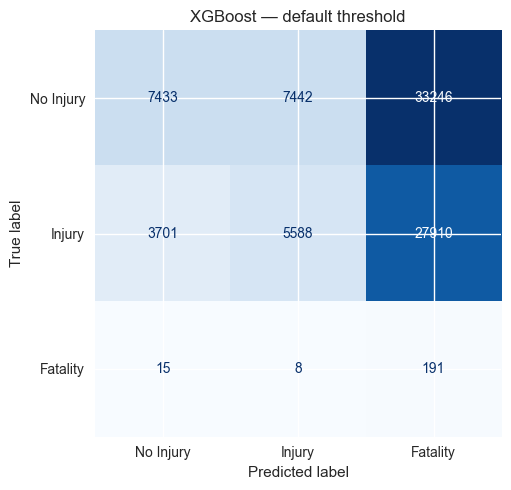

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_default),
                       display_labels=CLASS_NAMES).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('XGBoost — default threshold')
plt.tight_layout()
plt.show()

---
## 11. Threshold tuning for Fatality

Predict Fatality when P(Fatality) ≥ threshold. Sweep to find the best Fatality F1 point.

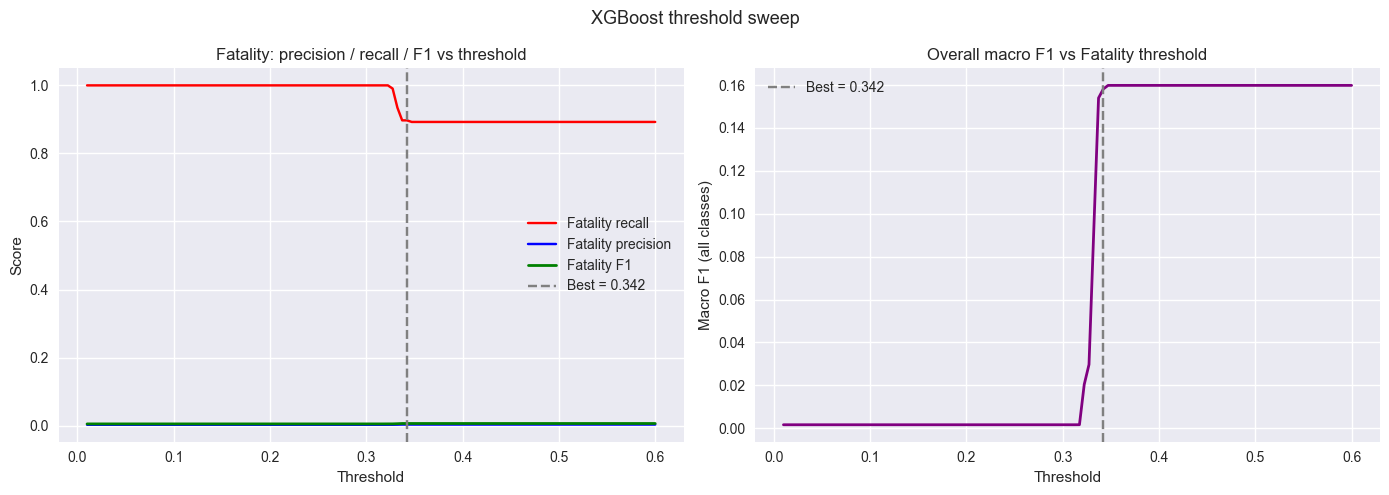

Best threshold:    0.3422
  Fatality recall:    0.8972
  Fatality precision: 0.0031
  Fatality F1:        0.0062
  Overall macro F1:   0.1581


In [12]:
fat_proba   = y_proba[:, 2]
thresholds  = np.linspace(0.01, 0.60, 120)
recalls, precisions, fat_f1s, macro_f1s = [], [], [], []

for t in thresholds:
    y_pred_t = np.where(fat_proba >= t, 2, y_pred_default)
    recalls.append(recall_score(y_test, y_pred_t, labels=[2], average='macro', zero_division=0))
    precisions.append(precision_score(y_test, y_pred_t, labels=[2], average='macro', zero_division=0))
    fat_f1s.append(f1_score(y_test, y_pred_t, labels=[2], average='macro', zero_division=0))
    macro_f1s.append(f1_score(y_test, y_pred_t, average='macro', zero_division=0))

recalls, precisions = np.array(recalls), np.array(precisions)
fat_f1s, macro_f1s  = np.array(fat_f1s),  np.array(macro_f1s)

best_idx    = np.argmax(fat_f1s)
best_thresh = thresholds[best_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.plot(thresholds, recalls,    label='Fatality recall',    color='red')
ax.plot(thresholds, precisions, label='Fatality precision', color='blue')
ax.plot(thresholds, fat_f1s,    label='Fatality F1',        color='green', linewidth=2)
ax.axvline(best_thresh, linestyle='--', color='gray', label=f'Best = {best_thresh:.3f}')
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title('Fatality: precision / recall / F1 vs threshold')
ax.legend(); ax.grid(True)

ax = axes[1]
ax.plot(thresholds, macro_f1s, color='purple', linewidth=2)
ax.axvline(best_thresh, linestyle='--', color='gray', label=f'Best = {best_thresh:.3f}')
ax.set_xlabel('Threshold'); ax.set_ylabel('Macro F1 (all classes)')
ax.set_title('Overall macro F1 vs Fatality threshold')
ax.legend(); ax.grid(True)

plt.suptitle('XGBoost threshold sweep', fontsize=13)
plt.tight_layout(); plt.show()

print(f"Best threshold:    {best_thresh:.4f}")
print(f"  Fatality recall:    {recalls[best_idx]:.4f}")
print(f"  Fatality precision: {precisions[best_idx]:.4f}")
print(f"  Fatality F1:        {fat_f1s[best_idx]:.4f}")
print(f"  Overall macro F1:   {macro_f1s[best_idx]:.4f}")

---
## 12. Evaluate with tuned threshold

In [13]:
y_pred_tuned = np.where(fat_proba >= best_thresh, 2, y_pred_default)

print(f"=== XGBoost — tuned threshold ({best_thresh:.4f}) ===")
print(classification_report(y_test, y_pred_tuned, target_names=CLASS_NAMES))
print(f"Macro F1:        {f1_score(y_test, y_pred_tuned, average='macro'):.4f}")
print(f"Fatality recall: {recall_score(y_test, y_pred_tuned, labels=[2], average='macro', zero_division=0):.4f}")
print(f"Fatality F1:     {f1_score(y_test, y_pred_tuned, labels=[2], average='macro', zero_division=0):.4f}")

=== XGBoost — tuned threshold (0.3422) ===
              precision    recall  f1-score   support

   No Injury       0.67      0.15      0.25     48121
      Injury       0.42      0.15      0.22     37199
    Fatality       0.00      0.90      0.01       214

    accuracy                           0.15     85534
   macro avg       0.36      0.40      0.16     85534
weighted avg       0.56      0.15      0.24     85534

Macro F1:        0.1581
Fatality recall: 0.8972
Fatality F1:     0.0062


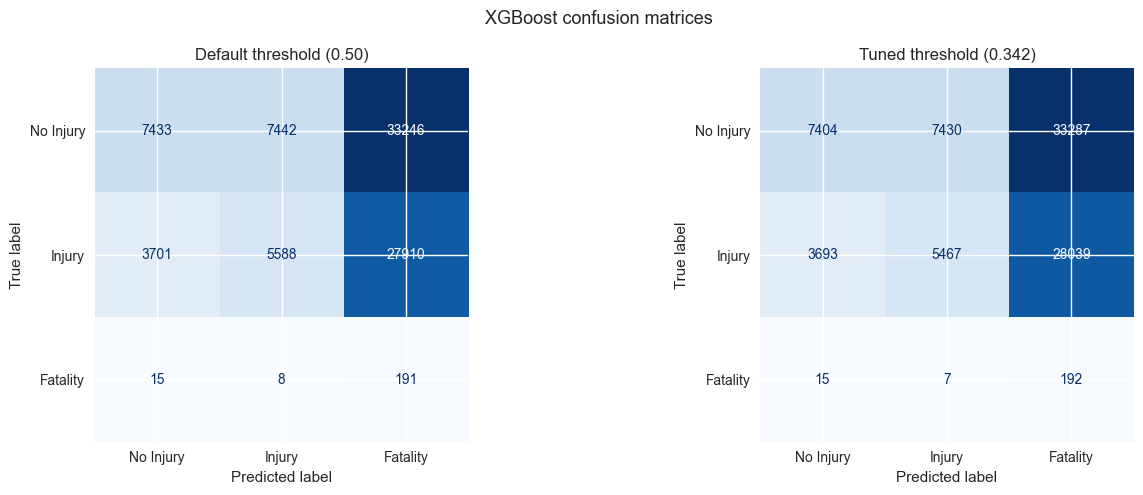

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_pred, title in zip(axes,
                              [y_pred_default, y_pred_tuned],
                              ['Default threshold (0.50)', f'Tuned threshold ({best_thresh:.3f})']):
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                           display_labels=CLASS_NAMES).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title)
plt.suptitle('XGBoost confusion matrices', fontsize=13)
plt.tight_layout(); plt.show()

---
## 13. Full model comparison

In [15]:
summary = pd.DataFrame([
    {'Model': 'Logistic Regression (baseline)',            'Macro F1': 0.430, 'Fatality Recall': 0.000, 'Injury Recall': 0.430},
    {'Model': 'Random Forest v1 (same features)',          'Macro F1': 0.430, 'Fatality Recall': 0.000, 'Injury Recall': 0.430},
    {'Model': 'RF cleaner model (feature eng.)',           'Macro F1': 0.471, 'Fatality Recall': 0.196, 'Injury Recall': 0.560},
    {'Model': 'RF + SMOTE (default thresh)',               'Macro F1': 0.497, 'Fatality Recall': 0.112, 'Injury Recall': 0.567},
    {
        'Model': 'XGBoost (default thresh)',
        'Macro F1':        round(f1_score(y_test, y_pred_default, average='macro'), 3),
        'Fatality Recall': round(recall_score(y_test, y_pred_default, labels=[2], average='macro', zero_division=0), 3),
        'Injury Recall':   round(recall_score(y_test, y_pred_default, labels=[1], average='macro', zero_division=0), 3),
    },
    {
        'Model': f'XGBoost (tuned thresh={best_thresh:.3f})',
        'Macro F1':        round(f1_score(y_test, y_pred_tuned, average='macro'), 3),
        'Fatality Recall': round(recall_score(y_test, y_pred_tuned, labels=[2], average='macro', zero_division=0), 3),
        'Injury Recall':   round(recall_score(y_test, y_pred_tuned, labels=[1], average='macro', zero_division=0), 3),
    },
])
print(summary.to_string(index=False))

                           Model  Macro F1  Fatality Recall  Injury Recall
  Logistic Regression (baseline)     0.430            0.000          0.430
Random Forest v1 (same features)     0.430            0.000          0.430
 RF cleaner model (feature eng.)     0.471            0.196          0.560
     RF + SMOTE (default thresh)     0.497            0.112          0.567
        XGBoost (default thresh)     0.160            0.893          0.150
    XGBoost (tuned thresh=0.342)     0.158            0.897          0.147


---
## 14. XGBoost feature importance (gain)

XGBoost's built-in gain importance measures the average improvement in loss brought by a feature
across all splits that use it — more interpretable than RF's impurity importance.

                                                        gain
factor_vehicle_2_UNKNOWN                         1127.368164
motorcycle_involved                              1012.376099
vehicle_type_2_UNKNOWN                            893.530212
vehicle_type_1_MOTORCYCLE                         788.582886
factor_vehicle_2_UNSPECIFIED                      788.132751
factor_vehicle_1_TRAFFIC CONTROL DISREGARDED      771.497559
factor_vehicle_1_PASSING TOO CLOSELY              744.629333
vehicle_type_2_SEDAN                              722.310486
factor_vehicle_1_UNSAFE SPEED                     694.275574
bike_involved                                     639.018677
factor_vehicle_1_FOLLOWING TOO CLOSELY            532.159851
factor_vehicle_1_DRIVER INATTENTION/DISTRACTION   476.080475
vehicle_type_1_SEDAN                              470.800018
factor_vehicle_1_DRIVER INEXPERIENCE              465.066162
is_rush_hour                                      464.401581
grid_cell_lat0_lon4     

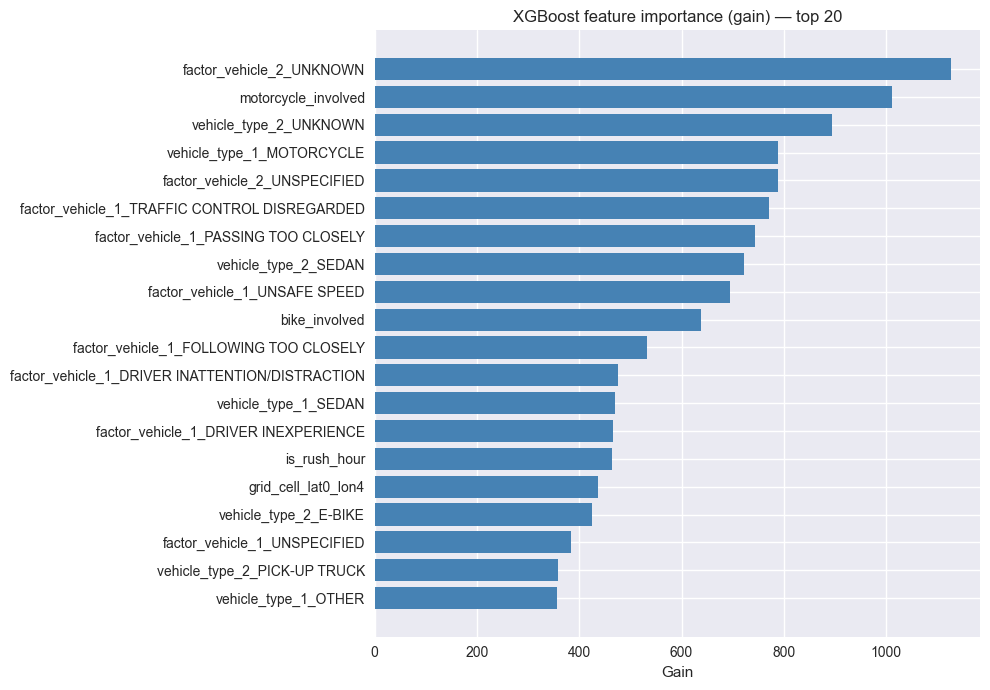

In [16]:
importance_raw = xgb_final.get_booster().get_score(importance_type='gain')
importance_df  = (
    pd.DataFrame.from_dict(importance_raw, orient='index', columns=['gain'])
    .sort_values('gain', ascending=False)
    .head(20)
)
print(importance_df.to_string())

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(importance_df.index[::-1], importance_df['gain'][::-1], color='steelblue')
ax.set_xlabel('Gain')
ax.set_title('XGBoost feature importance (gain) — top 20')
plt.tight_layout()
plt.show()

---
## 15. Next steps

If XGBoost still cannot push Fatality recall meaningfully higher, the remaining options are:

1. **SVM with RBF kernel** — may find a tighter Fatality cluster in the feature space that tree ensembles miss; requires `StandardScaler` first since SVM is distance-based.
2. **Two-stage model** — Stage 1: binary Fatality vs. Not-Fatality. Stage 2: No Injury vs. Injury for the non-fatality predictions. Lets each model specialize.
3. **More aggressive threshold** — if the recall curve in cell 11 shows large gains at lower thresholds, accept higher false positive rate to catch more fatalities.
4. **Feature audit** — features with near-zero gain in cell 14 can be dropped to reduce noise and retrain.